# LDM-rl 在 Isambard 上：数学、统计、结果

这份 notebook 回答四个问题，每个都有一张图和一句「这张图定了什么事」：

1. **零方差**——换 reward 和加轨迹各自值多少？（统计：单-run 的格怎么办）
2. **9B 起不来**——根因是什么，为什么修法只能是那一个？
3. **单节点装得下吗**——显存的账，以及原来那个「装不下」错在哪
4. **代价多大**——吞吐掉多少？

最后一节是**分母**：这些「每步多少」的比率，背后每个 run 能跑多少步。

机器：Isambard-AI，GH200（aarch64，驱动 565 / CUDA 12.7），每节点 4 张 95.6 GB 卡。


## 1. 零方差：把捆在一起的两个改动拆成 2×2

GRPO 的优势是 `(r − mean) / std`，**梯度来自组内差异**。一组里几条轨迹拿到同样的
reward，标准差为 0，这一组对参数更新一点贡献都没有——reward 再大也白搭。

陈奕杭的提议一次改两件事（reward 从 acquisition 换成 ΔHV，同时 `n_samples_per_prompt`
从 2 提到 4）。捆在一起，零方差降了也说不清是哪一件在起作用。所以把 n=2 那两格
也跑了，变成一个 2×2。

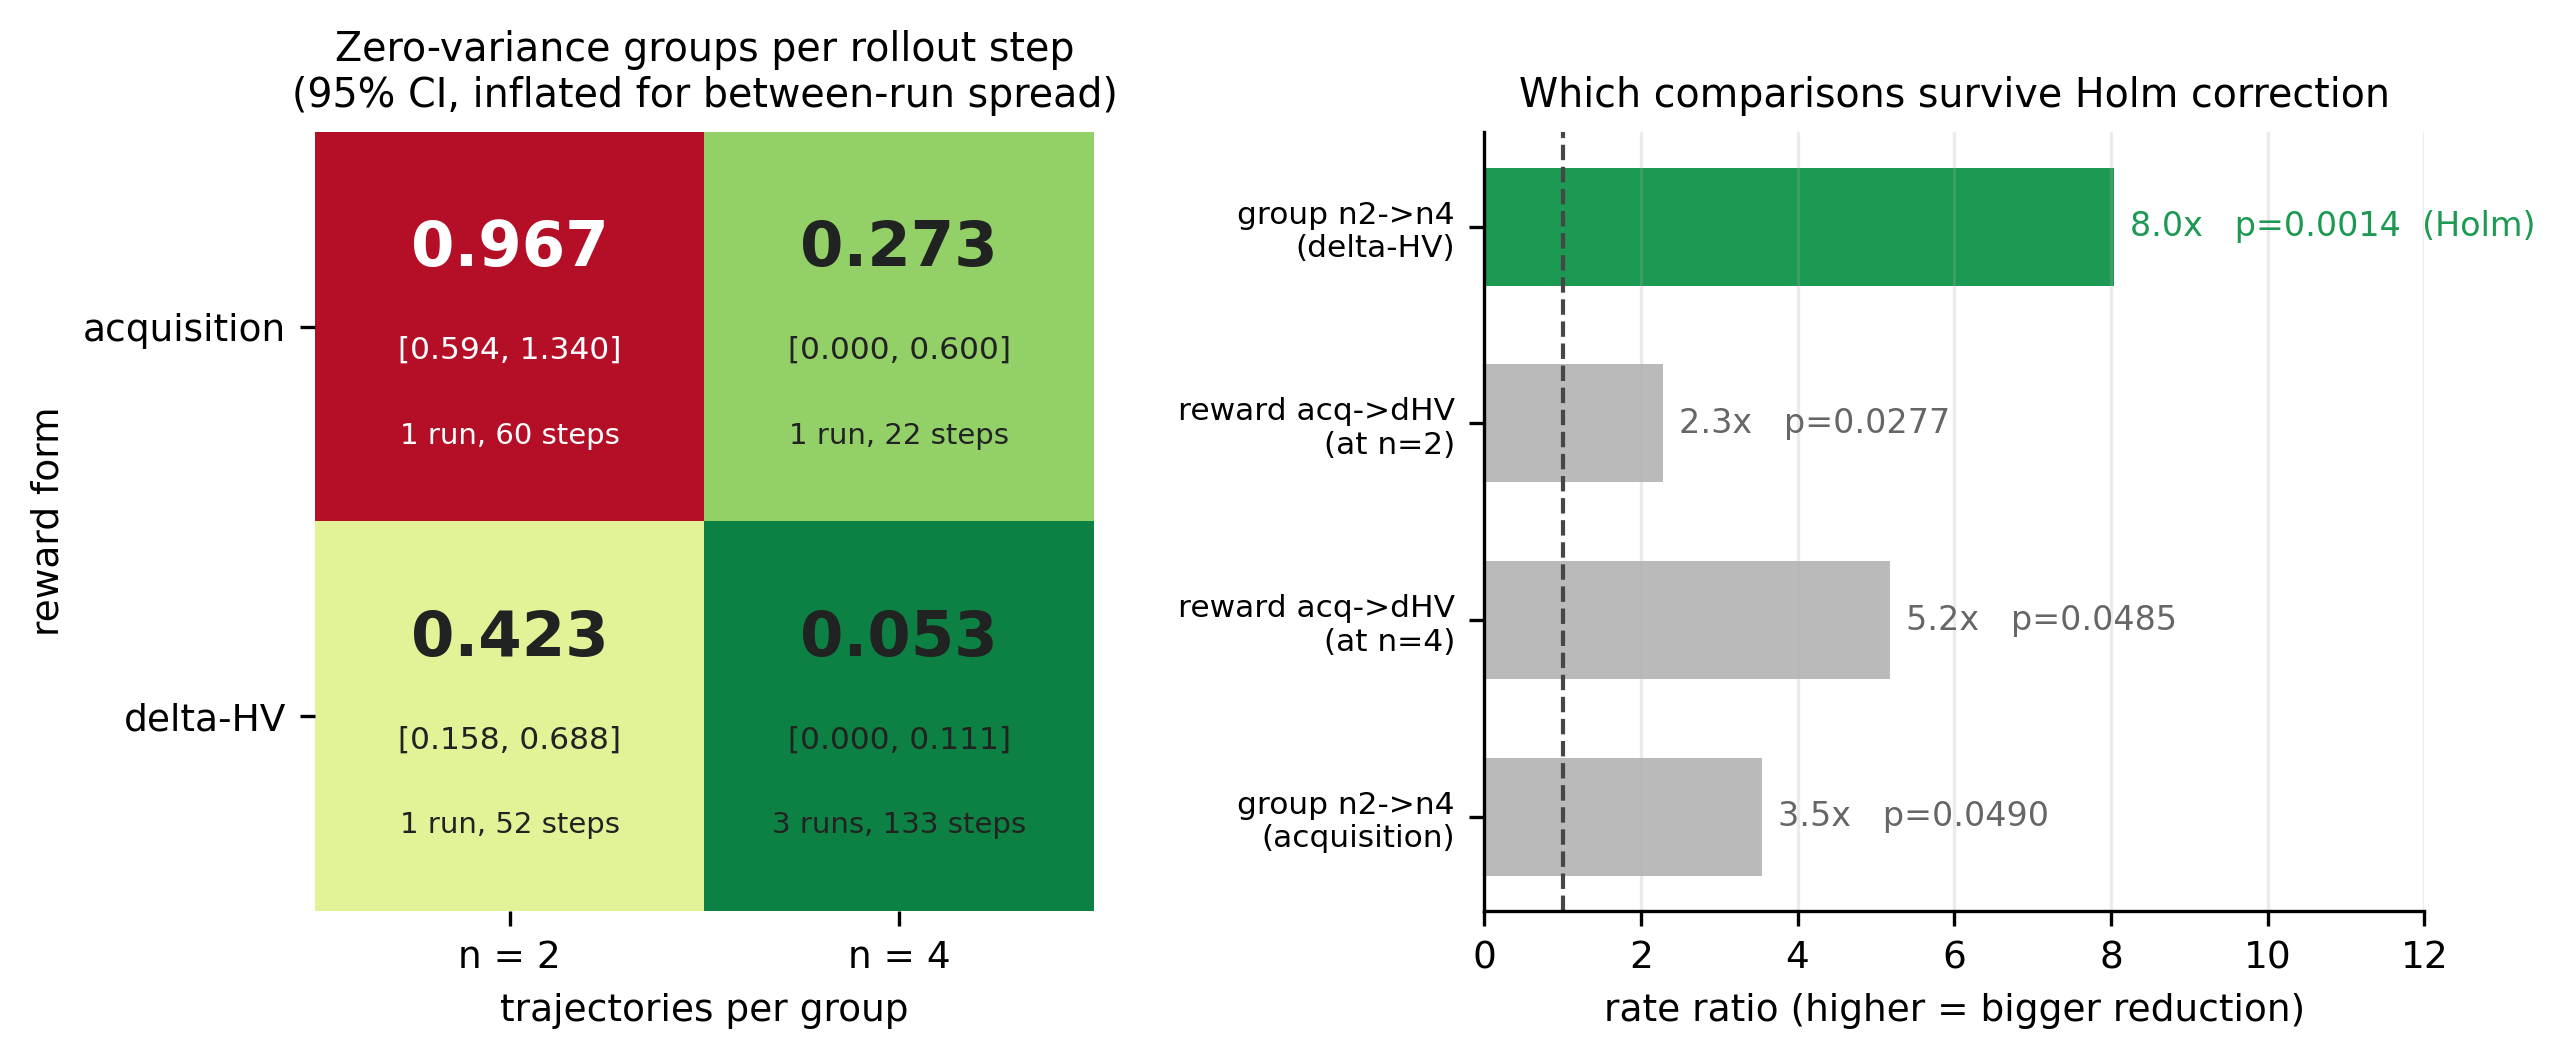

inflation factor 1.50x  (between-run SD 0.0222 / within-run SE 0.0199 = 1.12)


In [1]:
%matplotlib inline
import json, math, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})

# 300 dpi 是硬要求，但那会把 notebook 顶过 GitHub 内联渲染的上限（约 1 MB），
# 越过之后页面上只剩一句 Invalid Notebook。缩 figsize 不行——字号是磅值、
# 不随图缩小，缩完必然重叠。该动的是每像素几个字节：截成 256 色调色板 PNG。
# 这段必须待在 notebook 里：下一次 nbconvert --execute 会重跑所有 cell，
# 写在构建脚本外面的压缩会被那次重跑撤销。
import io
from PIL import Image
from IPython.display import display as _display, Image as _IPyImage
def _show(*a, **k):
    for num in plt.get_fignums():
        f = plt.figure(num)
        buf = io.BytesIO(); f.savefig(buf, format="png", bbox_inches="tight"); buf.seek(0)
        im = Image.open(buf).convert("RGB").quantize(colors=256, method=Image.MAXCOVERAGE)
        out = io.BytesIO(); im.save(out, format="PNG", optimize=True)
        _display(_IPyImage(data=out.getvalue())); plt.close(f)
plt.show = _show

R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results")
def load(n): return json.loads((R / n).read_text())

# ---- 统计工具：全篇共用，定义一次 -------------------------------------------
def inflation():
    """run 间波动相对 run 内计数噪声的放大倍数。

    单-run 的格给不出格内散布，泊松区间会不会盲目乐观？唯一能检验的是
    hypervolume_n4（3 个 run）。用它标定，再把系数用到其余格上——
    这是「用能测到的那一格去标定测不到的那三格」，也是这里唯一可行的办法。
    """
    c = load("reward_x_group.json")["cells"]["hypervolume_n4"]
    per = [x["zero_std_per_step"] for x in c["per_run"]]
    m = sum(per) / len(per)
    sd_b = math.sqrt(sum((x - m) ** 2 for x in per) / (len(per) - 1))
    se_w = math.sqrt(c["zero_std_total"]) / c["steps"]
    return math.sqrt(1 + (sd_b / se_w) ** 2), sd_b, se_w

def rate_ratio(ca, cb, inf):
    """对数率比及其 p 值。两个泊松计数，SE = sqrt(1/z1 + 1/z2)，再乘放宽系数。"""
    z1, n1 = ca["zero_std_total"], ca["steps"]
    z2, n2 = cb["zero_std_total"], cb["steps"]
    rr = (z1 / n1) / (z2 / n2)
    se = inf * math.sqrt(1 / z1 + 1 / z2)
    p = math.erfc(abs(math.log(rr) / se) / math.sqrt(2))
    return rr, se, p

rg = load("reward_x_group.json")["cells"]
INF, SD_B, SE_W = inflation()
KEYS = [["acquisition_n2","acquisition_n4"],["hypervolume_n2","hypervolume_n4"]]
vals = np.array([[rg[k]["zero_std_per_step"] for k in row] for row in KEYS])

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.6), gridspec_kw={"width_ratios":[1.05,1]})
ax = axes[0]
im = ax.imshow(vals, cmap="RdYlGn_r", vmin=0, vmax=1.0)
for i in range(2):
    for j in range(2):
        c = rg[KEYS[i][j]]
        z, n = c["zero_std_total"], c["steps"]
        se = INF*math.sqrt(max(z,1))/n
        col = "white" if vals[i,j] > .55 else "#222222"
        ax.text(j, i-.20, f'{vals[i,j]:.3f}', ha="center", va="center",
                fontsize=15, weight="bold", color=col)
        ax.text(j, i+.06, f'[{max(0,vals[i,j]-1.96*se):.3f}, {vals[i,j]+1.96*se:.3f}]',
                ha="center", va="center", fontsize=7.5, color=col)
        ax.text(j, i+.28, f'{c["runs_used"]} run{"s" if c["runs_used"]>1 else ""}, {n} steps',
                ha="center", va="center", fontsize=7, color=col)
ax.set_xticks([0,1]); ax.set_xticklabels(["n = 2","n = 4"])
ax.set_yticks([0,1]); ax.set_yticklabels(["acquisition","delta-HV"])
ax.set_xlabel("trajectories per group"); ax.set_ylabel("reward form")
ax.set_title("Zero-variance groups per rollout step\n(95% CI, inflated for between-run spread)", fontsize=9.5)
ax.grid(False)
for sp in ax.spines.values(): sp.set_visible(False)

ax = axes[1]
CMP = [("group n2->n4\n(delta-HV)",   "hypervolume_n2","hypervolume_n4"),
       ("reward acq->dHV\n(at n=2)",  "acquisition_n2","hypervolume_n2"),
       ("reward acq->dHV\n(at n=4)",  "acquisition_n4","hypervolume_n4"),
       ("group n2->n4\n(acquisition)","acquisition_n2","acquisition_n4")]
res = [(lab,)+rate_ratio(rg[a], rg[b], INF) for lab,a,b in CMP]
res.sort(key=lambda r: r[3])
k = len(res); still = True; verdicts = []
for i,(lab,rr,se,p) in enumerate(res):
    thr = 0.05/(k-i)
    ok = still and p < thr
    if not ok: still = False
    verdicts.append(ok)
y = np.arange(len(res))
ax.barh(y, [r[1] for r in res], color=["#1a9850" if v else "#bbbbbb" for v in verdicts], height=.6)
for i,((lab,rr,se,p),v) in enumerate(zip(res,verdicts)):
    ax.text(rr+.2, i, f'{rr:.1f}x   p={p:.4f}{"  (Holm)" if v else ""}',
            va="center", fontsize=8, color="#1a9850" if v else "#666666")
ax.set_yticks(y); ax.set_yticklabels([r[0] for r in res], fontsize=7.5)
ax.invert_yaxis(); ax.axvline(1, ls="--", lw=1, color="#444444")
ax.set_xlabel("rate ratio (higher = bigger reduction)"); ax.set_xlim(0, 12)
ax.set_title("Which comparisons survive Holm correction", fontsize=9.5)
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()
print(f"inflation factor {INF:.2f}x  (between-run SD {SD_B:.4f} / within-run SE {SE_W:.4f} = {SD_B/SE_W:.2f})")

**读法**：左边四格，往右往下都在降；**右边只有最上面那一条是绿的**。

四个对比方向全部一致（率比都 > 1），但**一次测了四个对比，必须做多重比较校正**。
Holm 之后只剩 `n=2 → n=4 在 ΔHV 下`（8.0×，p=0.0014）站得住；
另外三条原始 p 是 0.028 / 0.049 / 0.049，全贴着 0.05 的边，校正后都不成立。

**所以准确的说法是**：加轨迹在 ΔHV 下确定有效；换 reward 的独立效果**方向对但还没建立**。
（我此前在 PR 上写过「ΔHV 有独立于组内轨迹数的效果」——那句话过不了校正，已更正。）

方向一致性本身是另一个问题：4/4 个率比 > 1，符号检验 p = 0.125。
这一条不受多重比较影响（只问「整体方向」，只做一次检验），但四个对比给不出更多。

## 2. 统计上唯一的难处：三个格只有一个 run

四格里三格只有一个 run。单-run 给不出格内散布，那泊松区间会不会盲目乐观？

**唯一能检验这一点的是 `hypervolume_n4`**（3 个 run）。用它标定，再把系数用到其余格上。

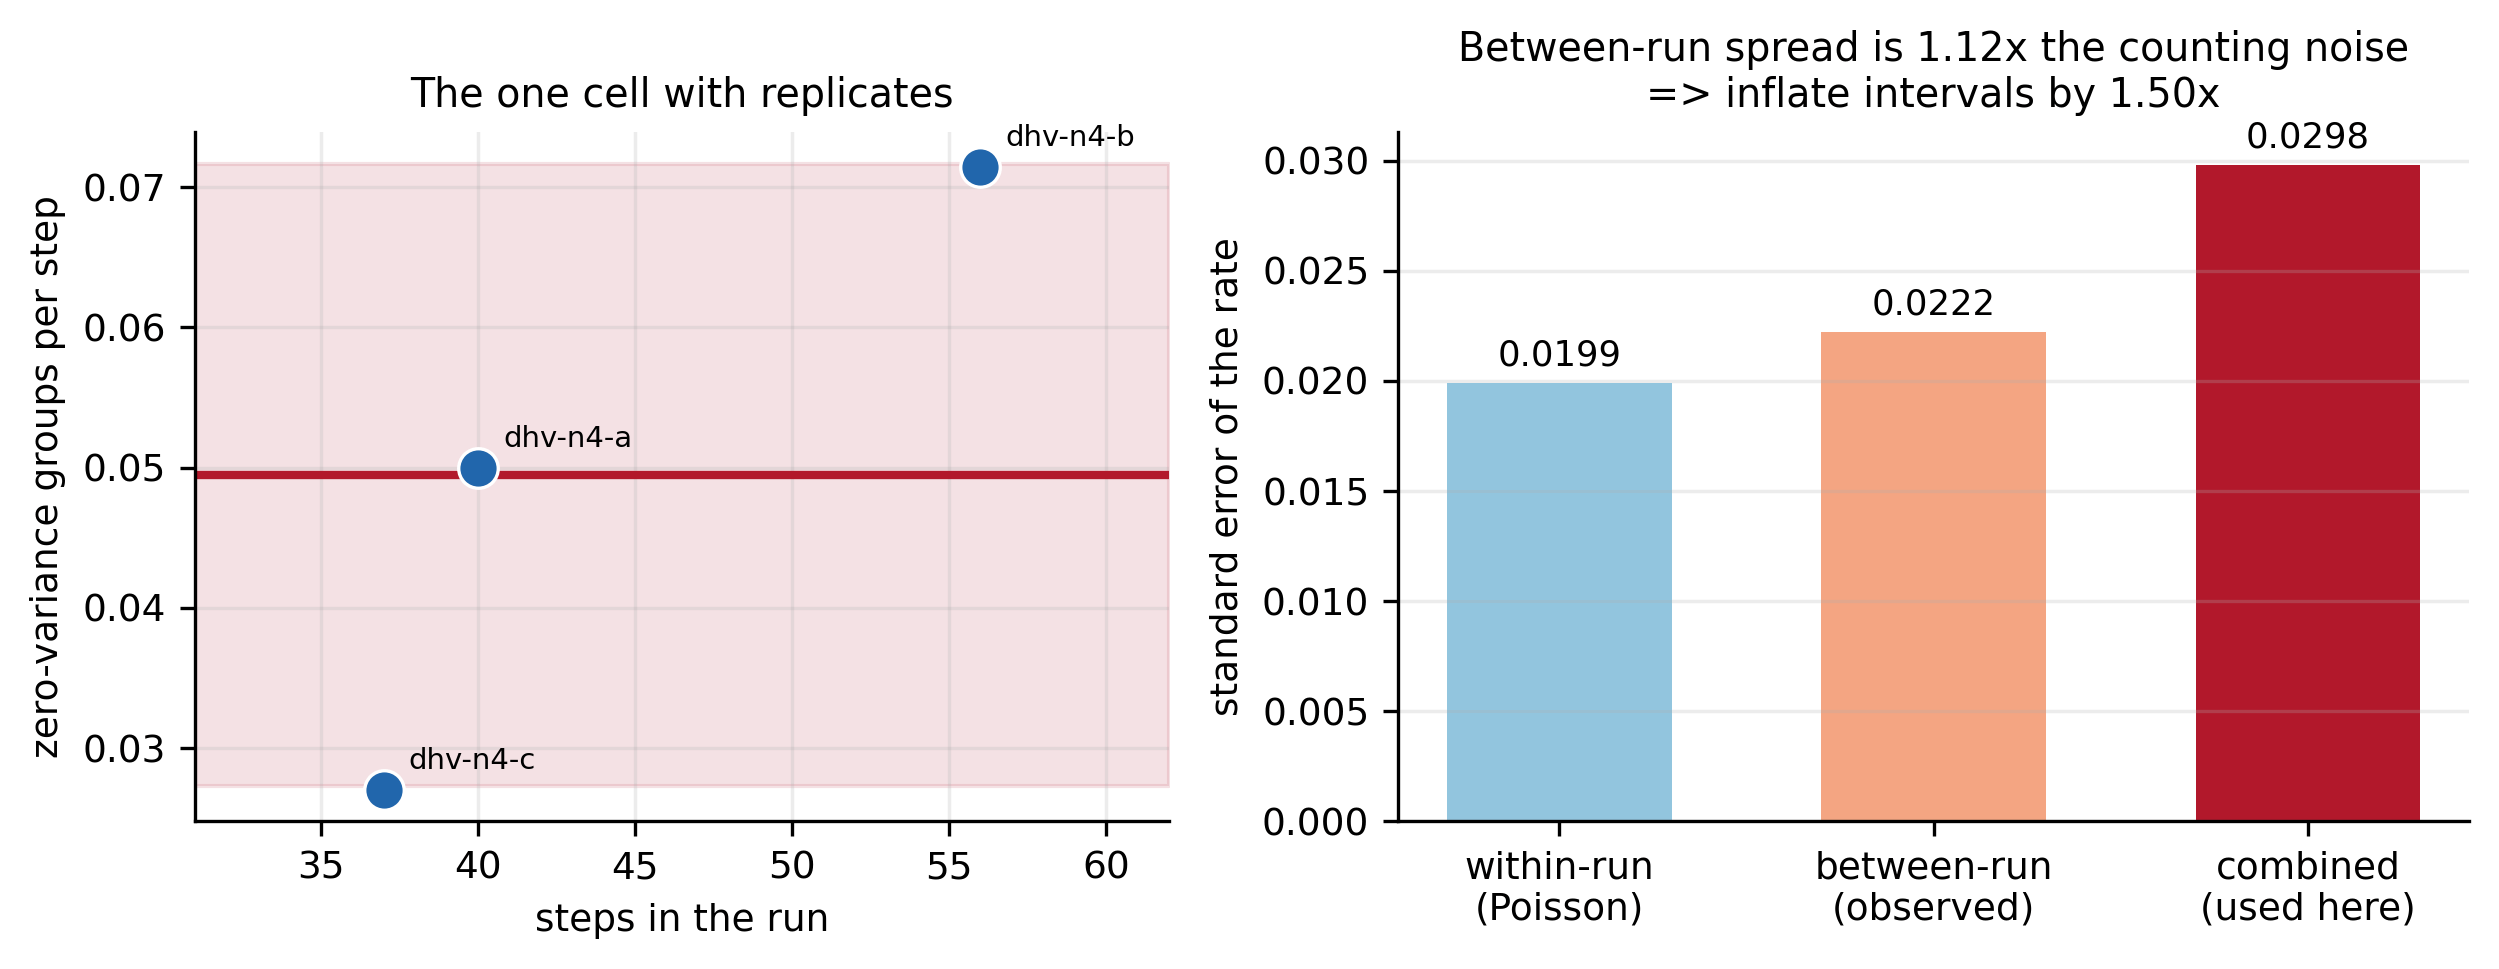

In [2]:
c = rg["hypervolume_n4"]
per = [x["zero_std_per_step"] for x in c["per_run"]]
steps = [x["steps"] for x in c["per_run"]]
m = sum(per)/len(per)
sd_b = math.sqrt(sum((x-m)**2 for x in per)/(len(per)-1))
se_w = math.sqrt(c["zero_std_total"])/c["steps"]

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.3), gridspec_kw={"width_ratios":[1,1.1]})
ax = axes[0]
ax.scatter(steps, per, s=90, color="#2166ac", zorder=3, edgecolors="white", linewidths=.8)
for s_, p_, r_ in zip(steps, per, c["per_run"]):
    ax.annotate(r_["run"], (s_, p_), textcoords="offset points", xytext=(6,5), fontsize=7)
ax.axhline(m, color="#b2182b", lw=2, zorder=2)
ax.fill_between([min(steps)-6, max(steps)+6], m-sd_b, m+sd_b, color="#b2182b", alpha=.12, zorder=1)
ax.set_xlim(min(steps)-6, max(steps)+6)
ax.set_xlabel("steps in the run"); ax.set_ylabel("zero-variance groups per step")
ax.set_title("The one cell with replicates", fontsize=9.5)

ax = axes[1]
bars = ax.bar(["within-run\n(Poisson)", "between-run\n(observed)", "combined\n(used here)"],
              [se_w, sd_b, math.sqrt(se_w**2+sd_b**2)],
              color=["#92c5de","#f4a582","#b2182b"], width=.6)
for b_, v in zip(bars, [se_w, sd_b, math.sqrt(se_w**2+sd_b**2)]):
    ax.text(b_.get_x()+b_.get_width()/2, v+.0008, f"{v:.4f}", ha="center", fontsize=8.5)
ax.set_ylabel("standard error of the rate")
ax.set_title(f"Between-run spread is {sd_b/se_w:.2f}x the counting noise\n"
             f"=> inflate intervals by {math.sqrt(1+(sd_b/se_w)**2):.2f}x", fontsize=9.5)
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**读法**：三个 run 的读数是 0.050 / 0.071 / 0.027，**run 间 SD 与计数噪声几乎相等**
（1.12 倍），不是它的十倍。

这个比值把另外三个单-run 的格从「不可解读」里救了回来：区间放宽 √(1 + 1.12²) = 1.50 倍
就够，不必因为 n=1 就整个作废。**用能测到的那一格去标定测不到的那三格**，
是这里唯一可行的办法——但它也只是标定，不是替代：真正的补法是把复现跑出来。

**注意区间重叠不是检验。** 差的标准误是 √(se₁²+se₂²)，比 se₁+se₂ 小；拿「两个区间
重不重叠」当判据，门槛大约是 p<0.006 而不是 0.05。上面用的是对数率比检验，不是重叠。

## 3. 9B 起不来：actor 的 TP 组被拆到两个节点

`slime/ray/placement_group.py` 只开**一个** placement group，里面装
`actor_gpus + rollout_gpus` 个 bundle，按 `(节点 IP, GPU 号)` 排序（`sort_key`），
然后把排在前面的 `actor_gpus` 个给 actor。

**没有任何东西把 actor 钉在一个节点上**——落不落得整齐，取决于哪个节点的
高速网地址数值更小：

| 谁的 IP 小 | 排序结果 | actor 拿到 |
|---|---|---|
| actor 节点 | `[a,a,a,a,r,r]` | 一个节点上的 4 张 ✓ |
| rollout 节点 | `[r,r,a,a,a,a]` | **两个节点各 2 张** ✗ |

拆了之后 TP 的 all-gather 要跨 Slingshot，倒在加载检查点的
`torch.distributed.checkpoint` gather：`NCCL Error 2: unhandled system error`。

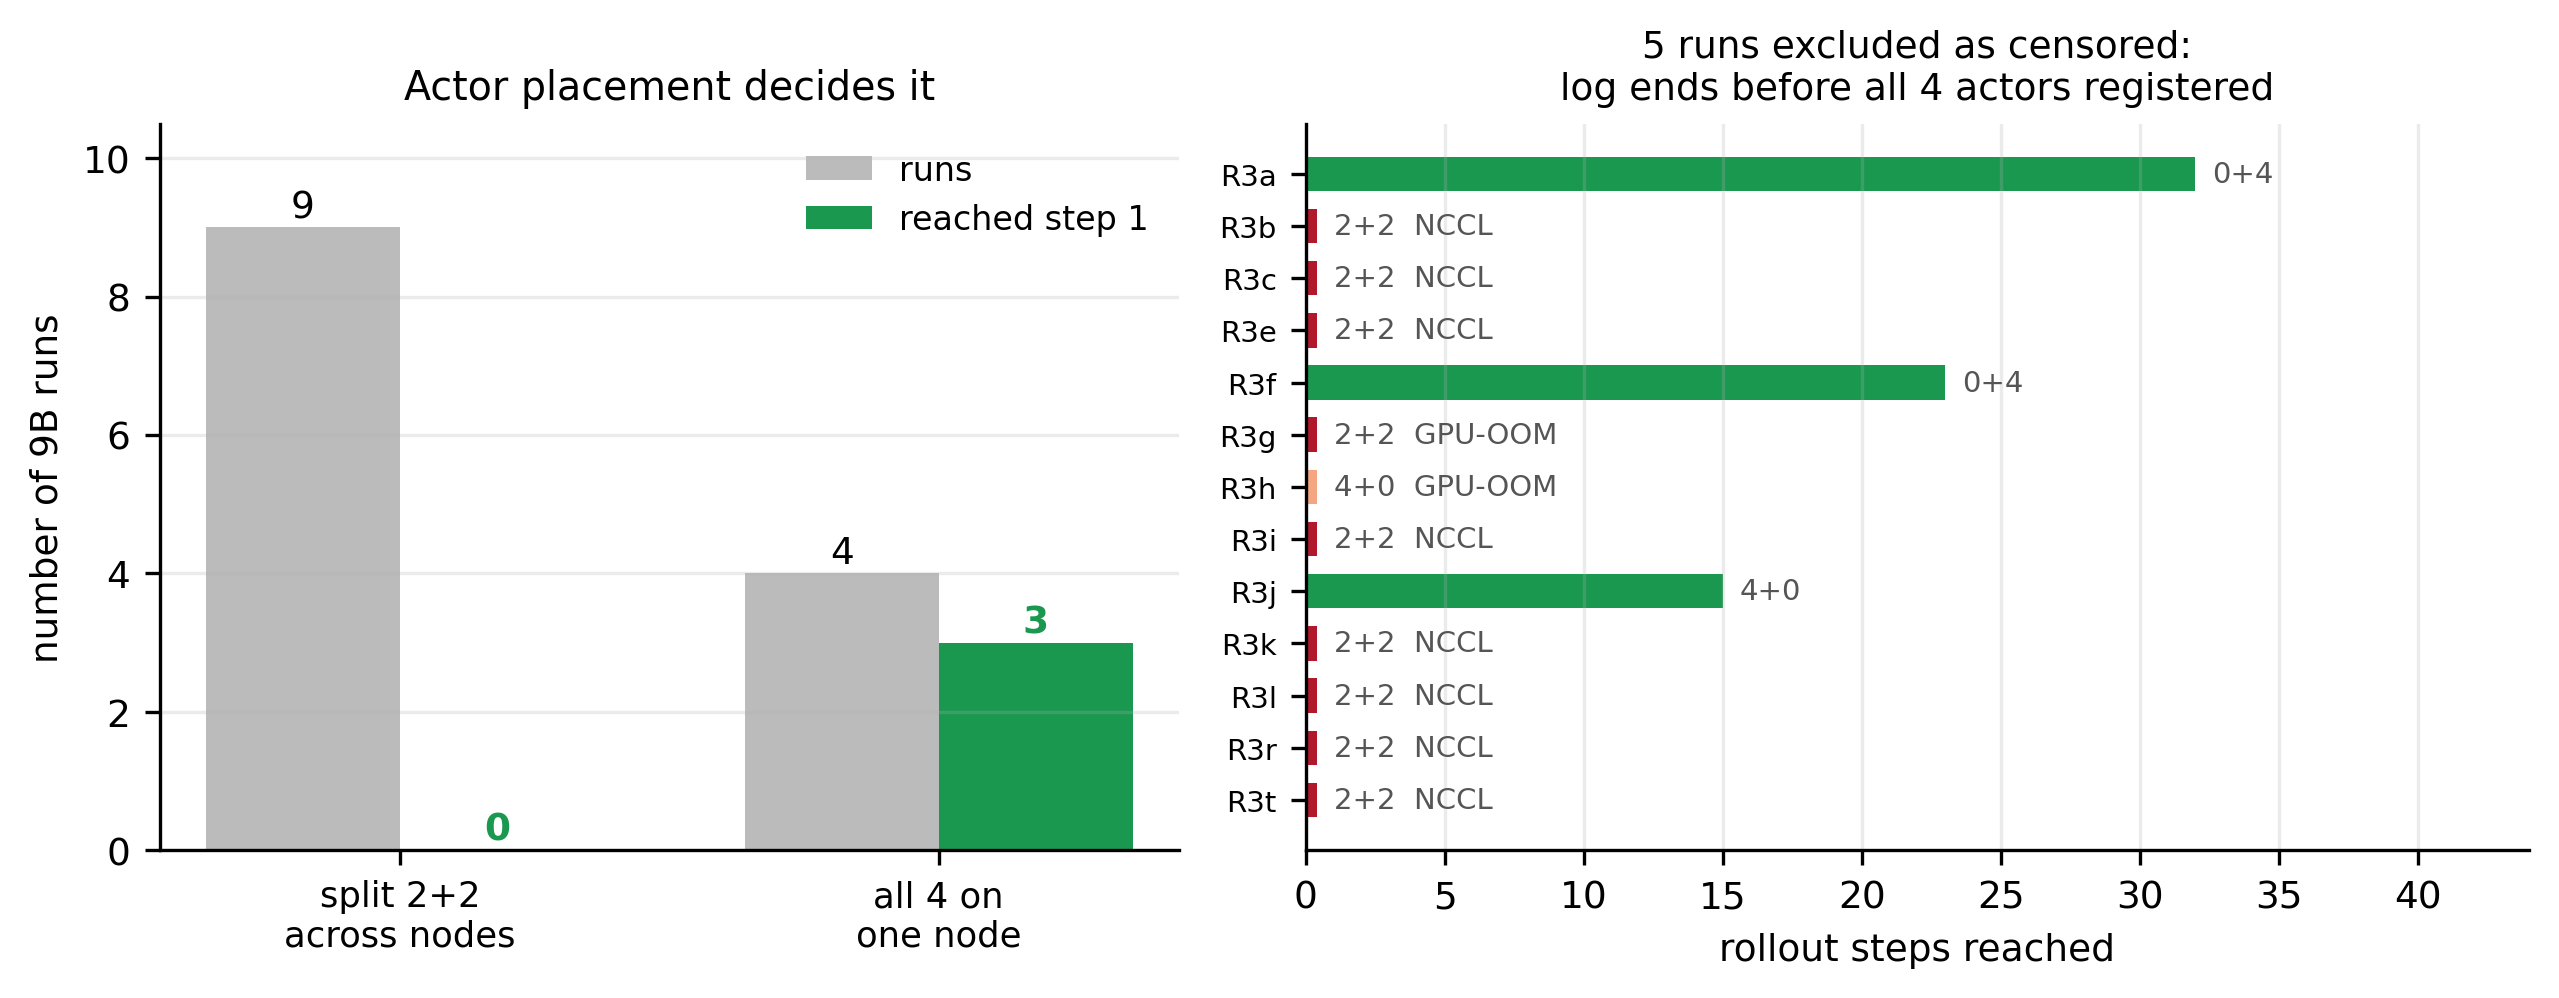

In [3]:
pl = load("nine_b_placement.json"); S = pl["summary"]
runs = [r for r in pl["runs"] if r["placement"] != "censored"]
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4), gridspec_kw={"width_ratios":[1,1.2]})

ax = axes[0]
cats = [("split 2+2\nacross nodes", S["split"]), ("all 4 on\none node", S["one_node"])]
x = np.arange(2)
ax.bar(x-.18, [c["runs"] for _,c in cats], width=.36, color="#bbbbbb", label="runs")
ax.bar(x+.18, [c["trained"] for _,c in cats], width=.36, color="#1a9850", label="reached step 1")
for i,(_,c) in enumerate(cats):
    ax.text(i-.18, c["runs"]+.15, str(c["runs"]), ha="center", fontsize=9)
    ax.text(i+.18, c["trained"]+.15, str(c["trained"]), ha="center", fontsize=9,
            color="#1a9850", weight="bold")
ax.set_xticks(x); ax.set_xticklabels([n for n,_ in cats], fontsize=8.5)
ax.set_ylabel("number of 9B runs"); ax.set_ylim(0, 10.5)
ax.set_title("Actor placement decides it", fontsize=9.5)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="x", alpha=0)

ax = axes[1]
y = np.arange(len(runs))
for i, r in enumerate(runs):
    c = "#1a9850" if r["trained"] else ("#b2182b" if r["placement"]=="split" else "#f4a582")
    ax.barh(i, max(r["steps"], .4), color=c, height=.66)
    tag = f'{r["on_head"]}+{r["on_remote"]}'
    if r["nccl_error"]: tag += "  NCCL"
    elif r["gpu_oom"]:  tag += "  GPU-OOM"
    ax.text(max(r["steps"], .4)+.6, i, tag, va="center", fontsize=7, color="#555555")
ax.set_yticks(y); ax.set_yticklabels([r["run"] for r in runs], fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("rollout steps reached"); ax.set_xlim(0, 44)
ax.set_title(f'{S["censored"]["runs"]} runs excluded as censored:\nlog ends before all 4 actors registered', fontsize=9)
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**读法**：**9 个被拆开的，0 个跑到第 1 步**，其中 8 个日志里有 `NCCL Error 2`。
整组落在一个节点上的 4 个里跑起来 3 个（32 / 23 / 15 步）。

例外那个（R3h）是另一回事：它那张卡上有两个邻居各占 29 GiB，显存撞死，不是 NCCL。

**右图故意排除了 5 个 run**：它们的日志在 actor 凑齐 4 个之前就断了，「0 步」的意思是
「还没来得及试」而不是「试了没成」。把它们算成失败，one-node 那列会凭空多 5 个零——
那正是我第一次读这张表时差点得出的结论。**一行写着「0 步」，可能是失败，也可能是
根本没轮到它试，而 placement 这一列分不出这两者。**

**跑起来的三个里有两个把 actor 全放在了「rollout 节点」上**，所以关键不是落在哪个节点，
是落在同一个节点。修法：起跑前解析两侧的 `10.100.*` 地址，把小的那个指派成 actor 节点。
必须取高速网地址——`getent hosts nid010873` 给的是 `10.242.12.139`，Ray 报的是
`10.100.29.20`，同一台机器两个网段，**之间不保序**。

## 4. 单节点装得下吗：显存的账

陈奕杭提议改用单节点绕开上面那个缺陷。这个布局此前被判为「装不下」——
2026-09-01 实测，TE 的 `fused_adam` 惰性分配 `exp_avg_sq` 时只剩 490 MiB。

**但那个结论少了一个限定词。** 14 字节/参数不是模型的性质，是「优化器状态怎么存」
的选择。记录里写成了「9B 单节点装不下」，丢掉限定词之后，一条能解除的约束被当成了硬墙。

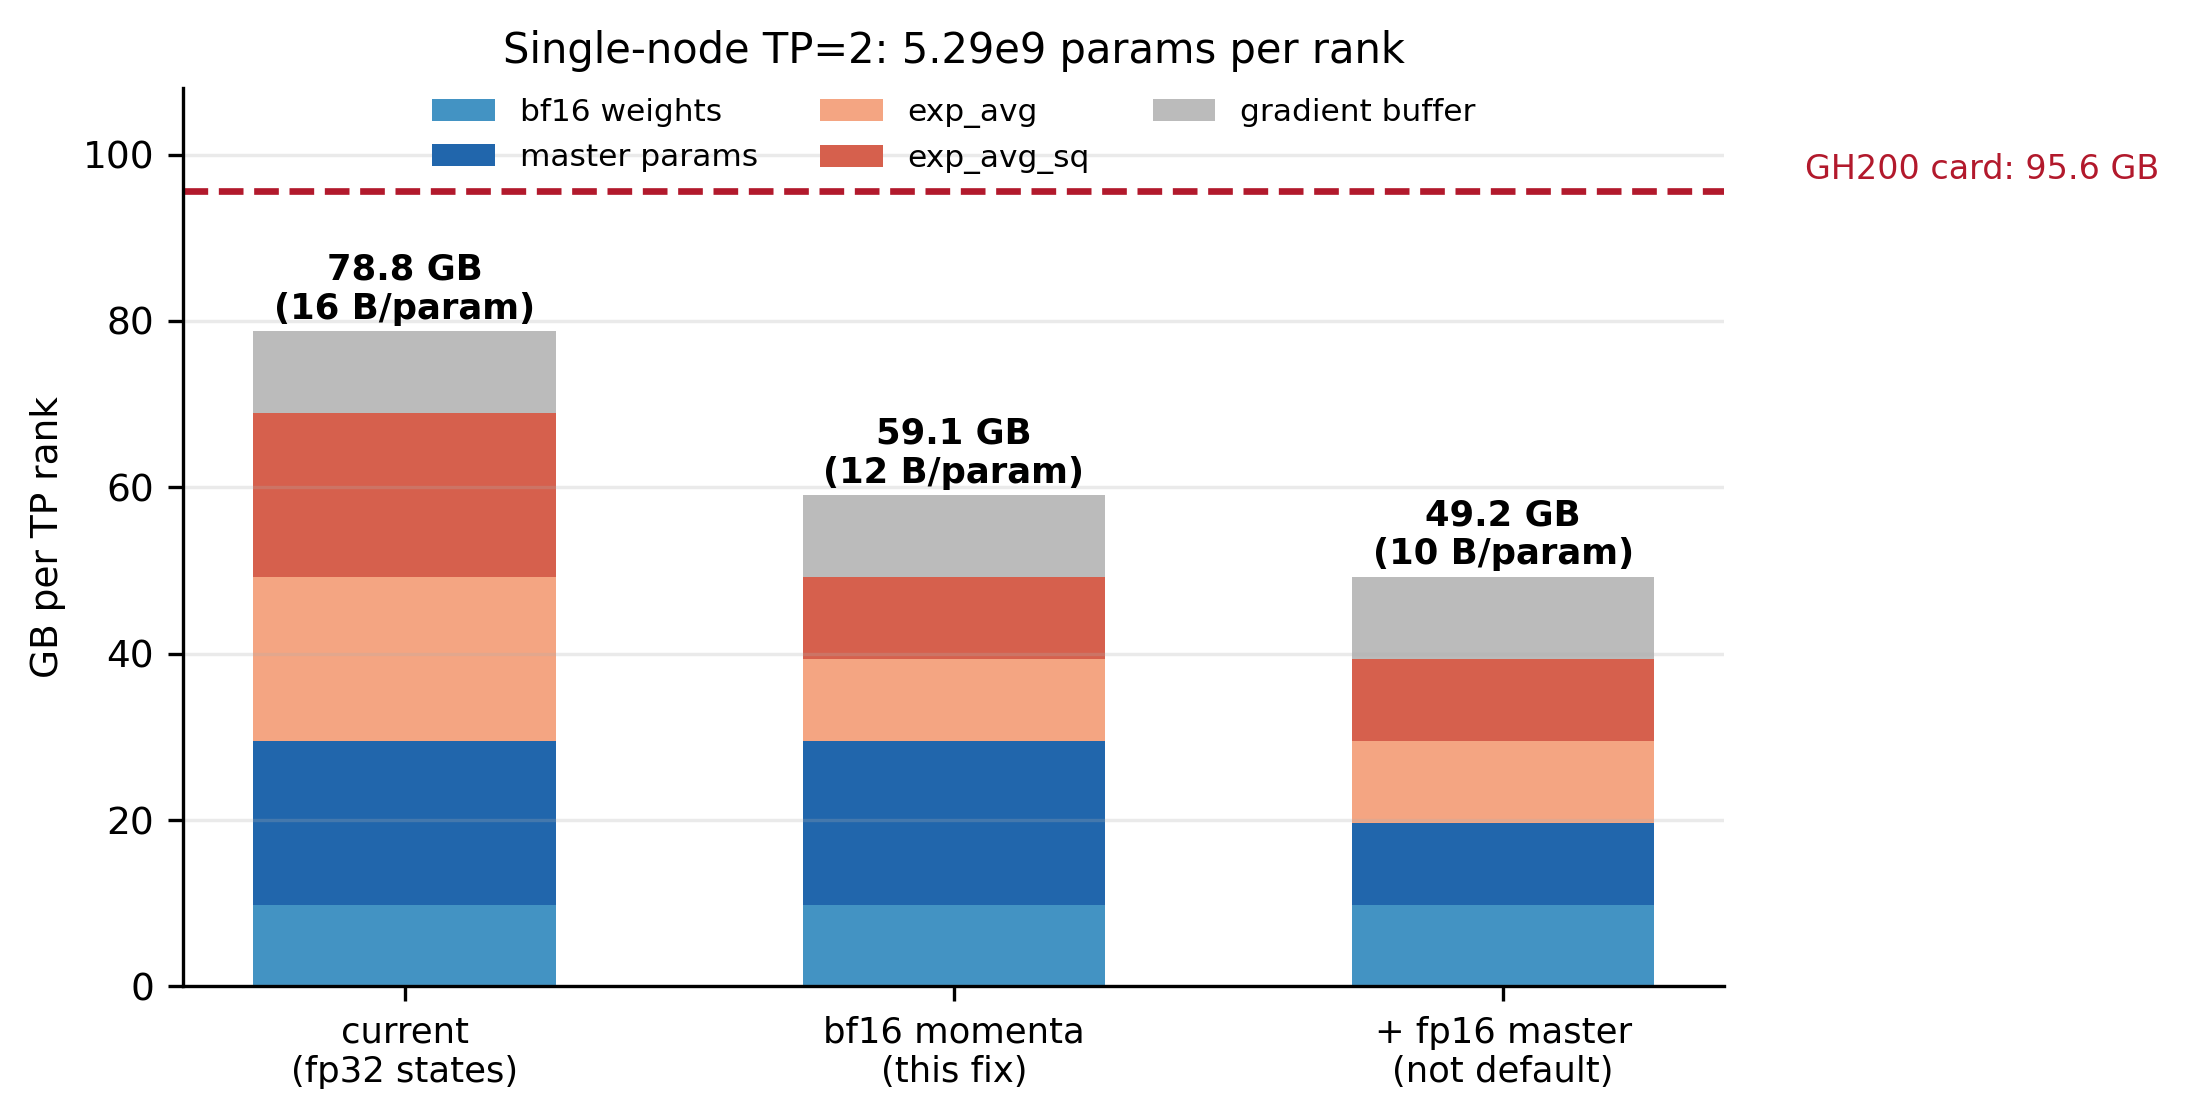

current (fp32 states)             16 B/param    78.8 GB  fits
bf16 momenta (this fix)           12 B/param    59.1 GB  fits
+ fp16 master (not default)       10 B/param    49.2 GB  fits


In [4]:
P = 5_285_884_416          # 每个 TP rank 的参数量（TP=2，实测值）
GB = 1024**3
CARD = 95.6

# 每一项的字节数/参数。梯度缓冲是分布式优化器单独持有的一块，
# 与优化器状态是两笔账 —— 原来那个 74 GB 的算法把它漏了。
layouts = {
  "current\n(fp32 states)": dict(w=2, master=4, m1=4, m2=4, grad=2),
  "bf16 momenta\n(this fix)": dict(w=2, master=4, m1=2, m2=2, grad=2),
  "+ fp16 master\n(not default)": dict(w=2, master=2, m1=2, m2=2, grad=2),
}
order = ["w","master","m1","m2","grad"]
lab   = {"w":"bf16 weights","master":"master params","m1":"exp_avg","m2":"exp_avg_sq",
         "grad":"gradient buffer"}
col   = {"w":"#4393c3","master":"#2166ac","m1":"#f4a582","m2":"#d6604d","grad":"#bbbbbb"}

fig, ax = plt.subplots(figsize=(7.4, 3.8))
x = np.arange(len(layouts)); bottom = np.zeros(len(layouts))
for k in order:
    v = np.array([lay[k]*P/GB for lay in layouts.values()])
    ax.bar(x, v, .55, bottom=bottom, color=col[k], label=lab[k])
    bottom += v
for i,(name,lay) in enumerate(layouts.items()):
    tot = sum(lay[k] for k in order)*P/GB
    ax.text(i, tot+1.5, f"{tot:.1f} GB\n({sum(lay[k] for k in order)} B/param)",
            ha="center", fontsize=8.5, weight="bold")
ax.axhline(CARD, color="#b2182b", ls="--", lw=1.6)
ax.text(len(layouts)-.45, CARD+1.5, f"GH200 card: {CARD} GB", fontsize=8, color="#b2182b")
ax.set_xticks(x); ax.set_xticklabels(list(layouts), fontsize=8.5)
ax.set_ylabel("GB per TP rank"); ax.set_ylim(0, 108)
ax.set_title(f"Single-node TP=2: {P/1e9:.2f}e9 params per rank", fontsize=10)
ax.legend(frameon=False, fontsize=7.5, ncol=3, loc="upper center", bbox_to_anchor=(.5,1.02))
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()
for name, lay in layouts.items():
    print(f'{name.replace(chr(10)," "):32} {sum(lay[k] for k in order):>3} B/param'
          f'  {sum(lay[k] for k in order)*P/GB:>6.1f} GB'
          f'  {"fits" if sum(lay[k] for k in order)*P/GB < CARD else "OVER"}')

**读法**：现状 84.7 GB 顶在 95.6 GB 的线下面，剩下的余量要装激活和 CUDA/NCCL
上下文——**所以它是在最后一次分配上死的**（只剩 490 MiB），不是一开始就装不下。

把两个动量存成 bf16：14 → 10 字节/参数，**84.7 GB → 63.5 GB**，留出 32 GB 余量。
主权重**故意保持 fp32**——那是 Adam 累加更新的地方，降到 fp16 是拿收敛换我们并不需要的余量。

**原来那个 74 GB 的算法在两个方向上都不准**：它**漏了**梯度缓冲（真实上限比记的更紧），
但**不该算**参考模型——slime 把 ref/old_actor 备份在固定页的 CPU 内存里
（`slime/utils/tensor_backper.py:59`，`device="cpu", pin_memory=True`），
GH200 的 NVLink-C2C 约 450 GB/s，取回很便宜。

已实测生效：日志里 `use_precision_aware_optimizer=True`、
`exp_avg_dtype=torch.bfloat16`、`main_params_dtype=torch.float32`。

## 5. 代价多大：训练只占单步的 1.7%

单节点把 actor 从 4 张卡（TP=4）减到 2 张（TP=2），每 rank 的训练计算量翻倍。
问题是训练在一步里本来占多少。

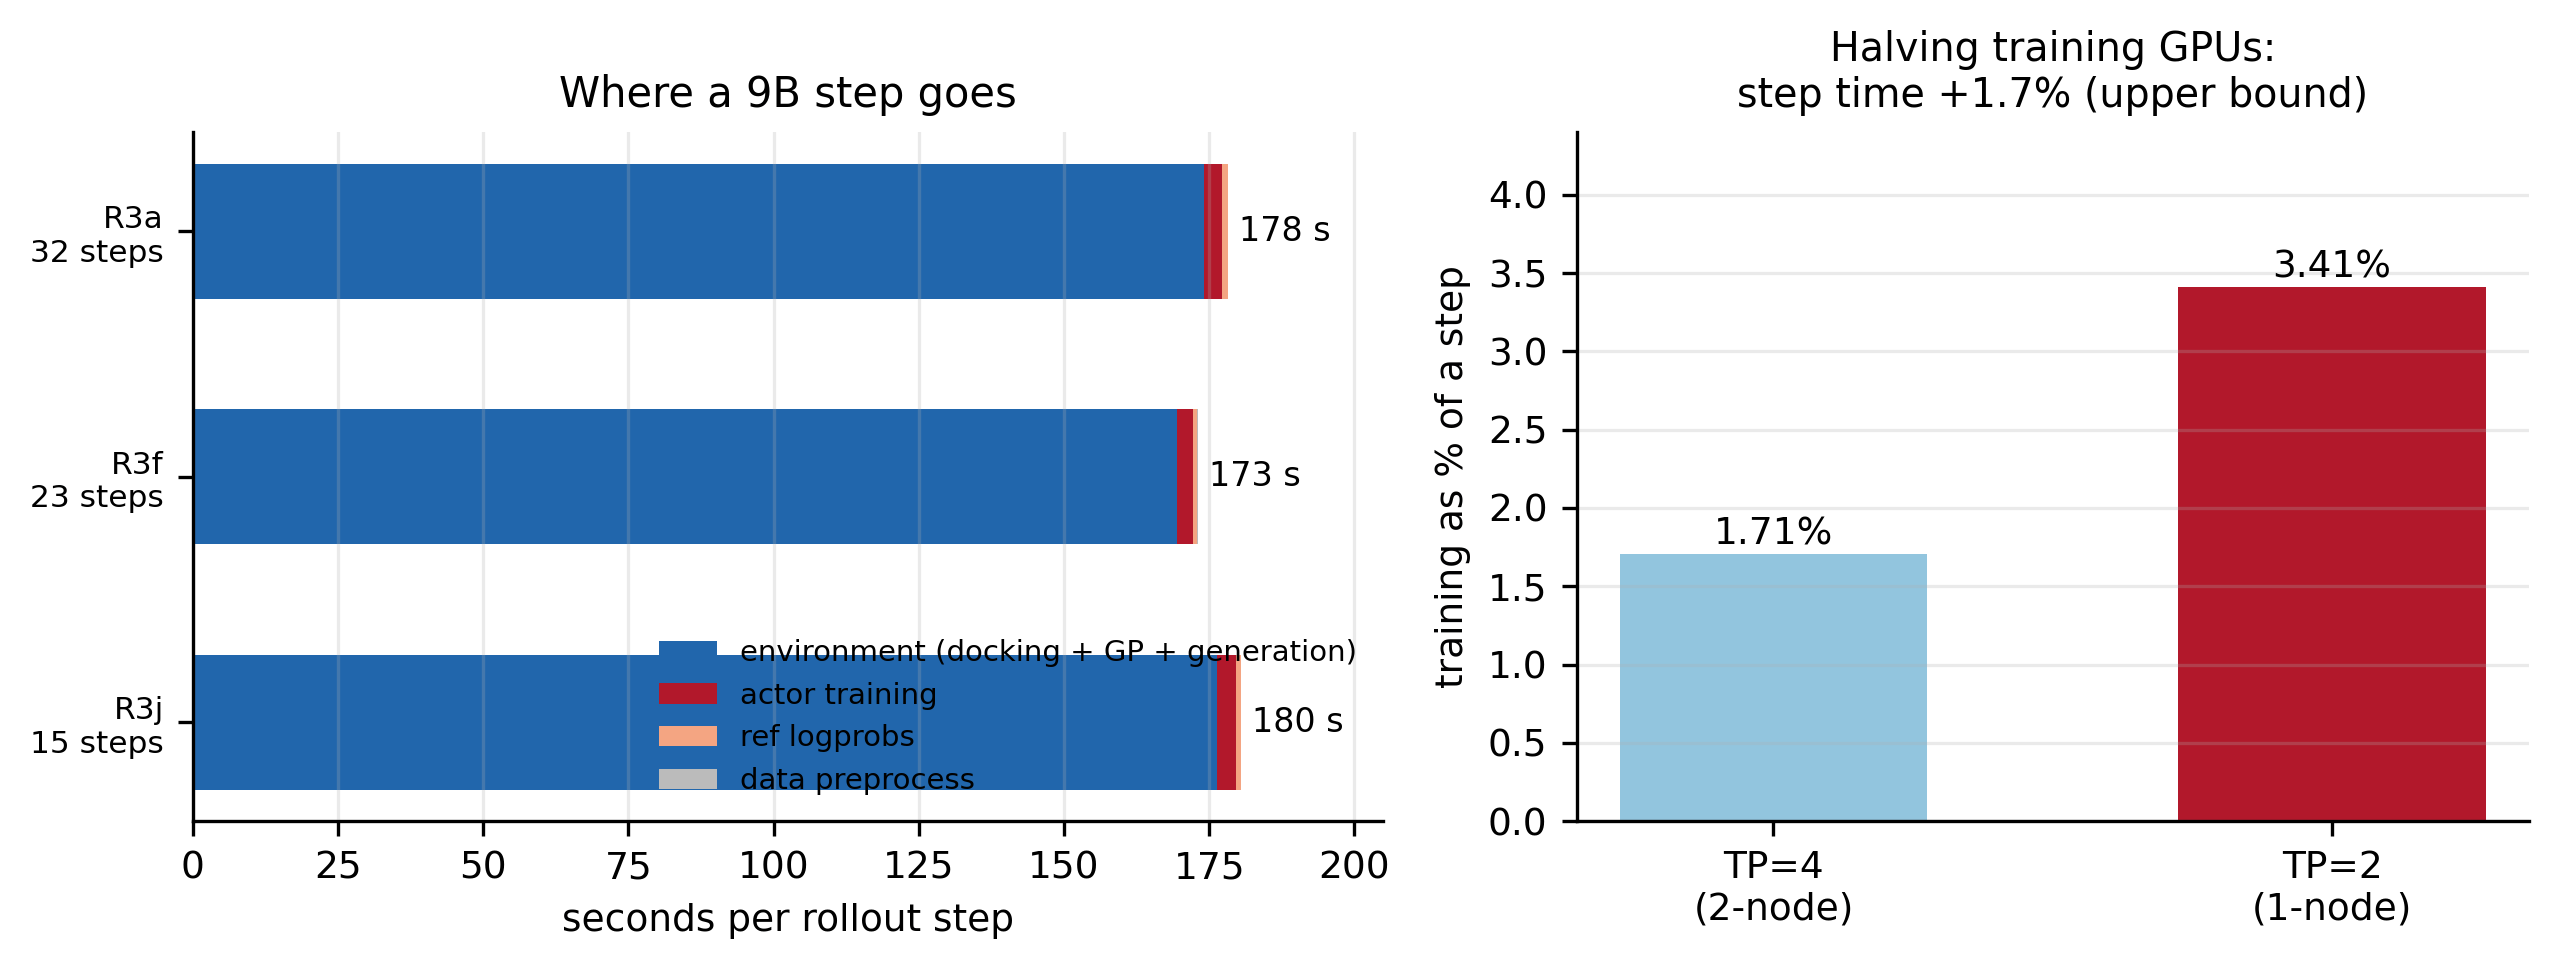

training share 1.61% - 1.76% across 3 runs (mean 1.71%)


In [5]:
sb = load("step_breakdown.json"); rows = sb["runs"]; S = sb["summary"]
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.3), gridspec_kw={"width_ratios":[1.25,1]})

ax = axes[0]
parts = [("rollout_time","environment (docking + GP + generation)","#2166ac"),
         ("actor_train_time","actor training","#b2182b"),
         ("ref_log_probs_time","ref logprobs","#f4a582"),
         ("data_preprocess_time","data preprocess","#bbbbbb")]
y = np.arange(len(rows)); left = np.zeros(len(rows))
for key, name, c in parts:
    v = np.array([r[key] for r in rows])
    ax.barh(y, v, .55, left=left, color=c, label=name); left += v
for i, r in enumerate(rows):
    ax.text(r["total_s"]+2, i, f'{r["total_s"]:.0f} s', va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels([f'{r["run"]}\n{r["steps"]} steps' for r in rows], fontsize=7.5)
ax.invert_yaxis(); ax.set_xlabel("seconds per rollout step"); ax.set_xlim(0, 205)
ax.set_title("Where a 9B step goes", fontsize=10)
ax.legend(frameon=False, fontsize=7, loc="lower right"); ax.grid(axis="y", alpha=0)

ax = axes[1]
share = S["train_share_mean"]
bars = ax.bar(["TP=4\n(2-node)","TP=2\n(1-node)"],
              [100*share, 100*share*2], color=["#92c5de","#b2182b"], width=.55)
for b_, v in zip(bars, [100*share, 100*share*2]):
    ax.text(b_.get_x()+b_.get_width()/2, v+.06, f"{v:.2f}%", ha="center", fontsize=9)
ax.set_ylabel("training as % of a step"); ax.set_ylim(0, 4.4)
ax.set_title(f"Halving training GPUs:\nstep time +{100*share:.1f}% (upper bound)", fontsize=9.5)
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()
print(f'training share {100*S["train_share_min"]:.2f}% - {100*S["train_share_max"]:.2f}% '
      f'across {S["runs"]} runs (mean {100*S["train_share_mean"]:.2f}%)')

**读法**：97.7% 的时间在 `rollout_time`——docking 加 GP 拟合。训练是 1.7%。

所以训练时间最坏翻倍，整步从 178 s 变成 181 s，**+1.7%**。而且这是上界：
TP=4 → TP=2 时每 rank 的环形 all-reduce 字节数**反而下降**
（`2(N-1)/N`：N=4 是 1.5S，N=2 是 1.0S），所以训练不到翻倍。

**「训练卡少一半」听起来像「慢一半」，实测是慢 1.7%**——瓶颈根本不在训练侧。
三个 run 的训练占比落在 1.61–1.76%，结论不靠单次测量撑着。

取的是**最后一次读数不是均值**：第 1 步含 CUDA graph 捕获与 kernel 自动调优
（`actor_train_tflops` 第 1 步读 21–50、之后 ~130，同样的活、不同的分母），
平均进去会把训练成本低估。

## 6. 分母：每个 run 能跑多少步

上面所有的率都是「每步多少」。**一个 run 能跑几步，是这些数字的上游。**

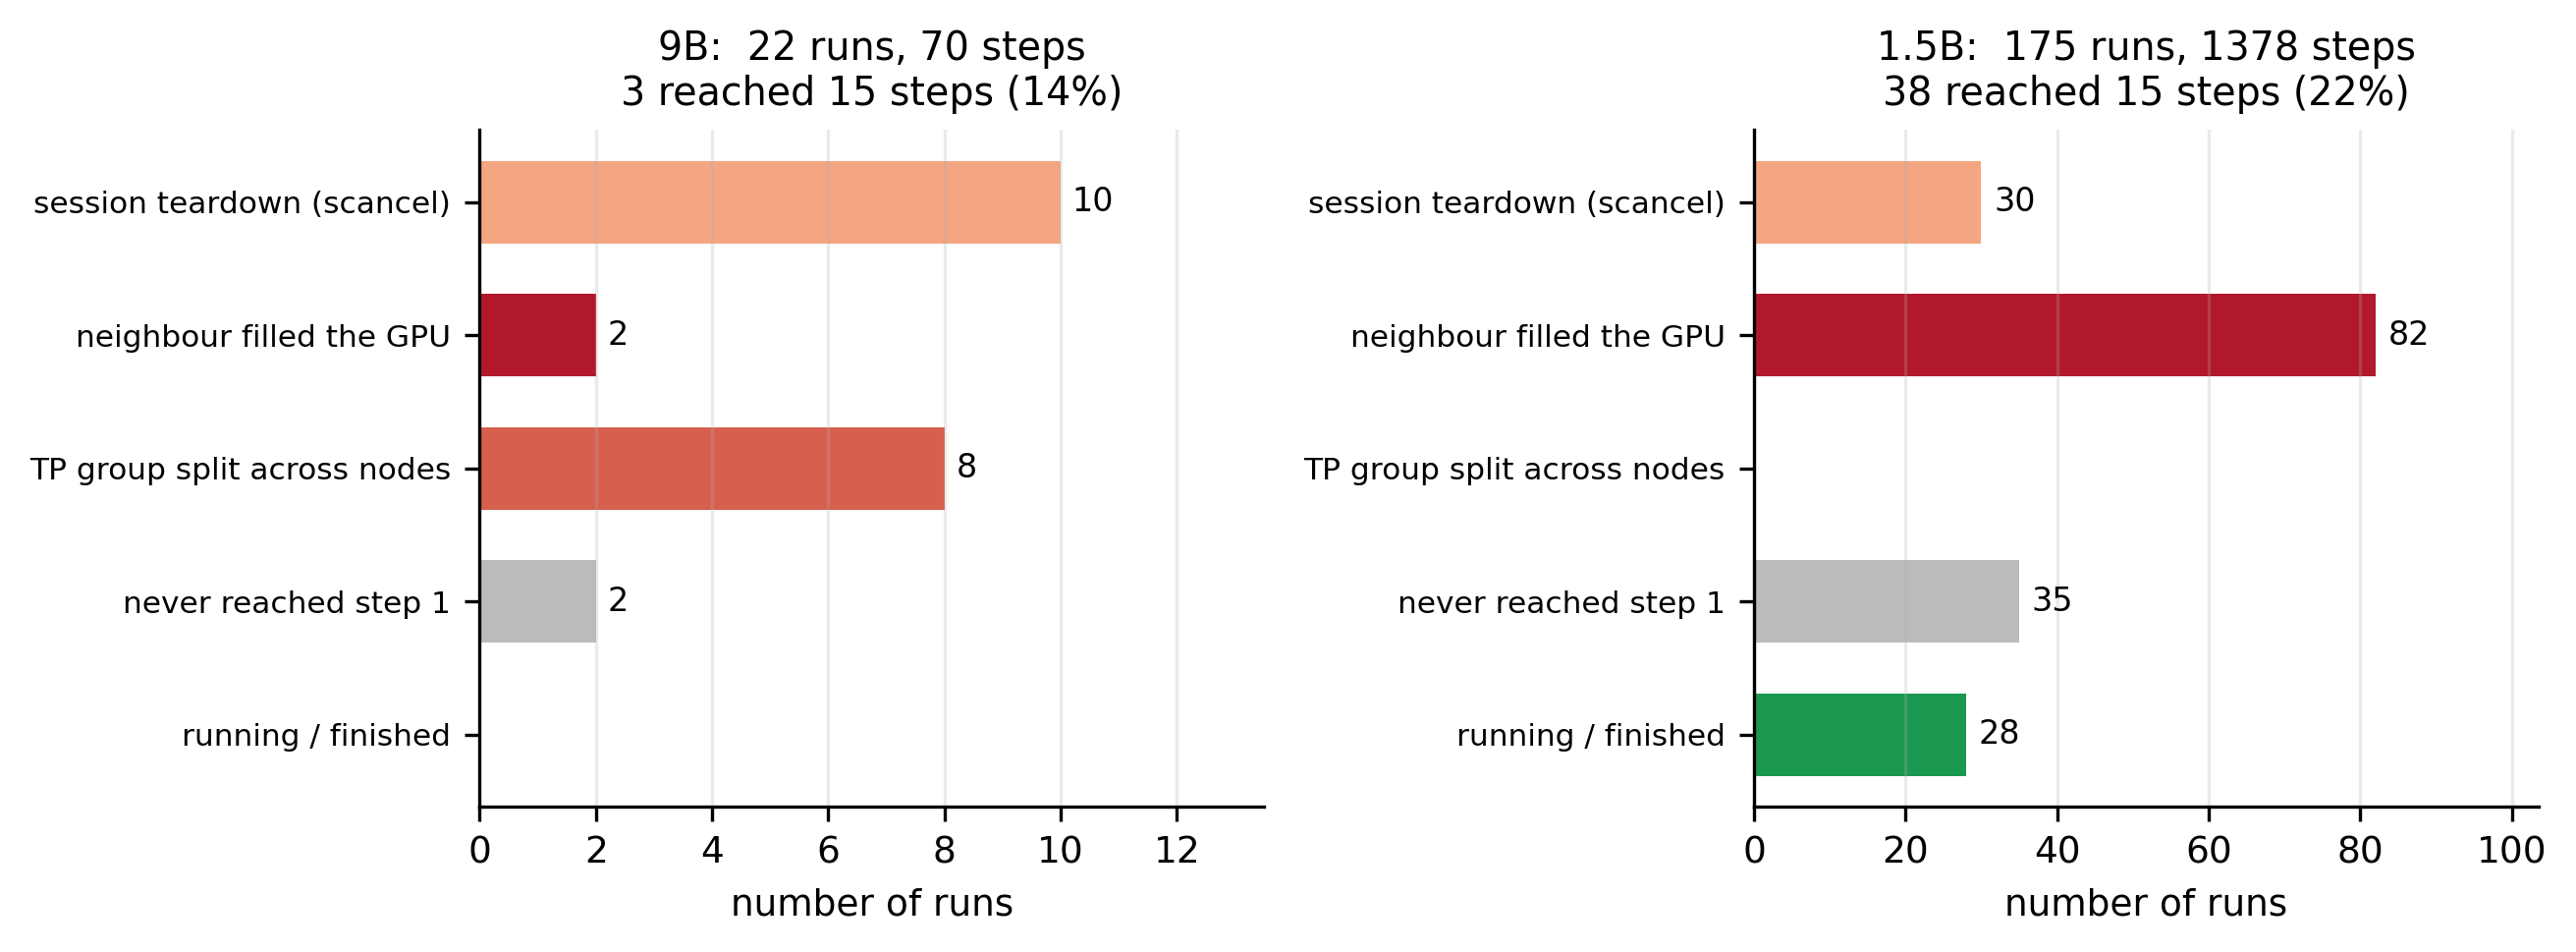

In [6]:
mo = load("run_mortality.json"); S = mo["summary"]
CAUSES = ["session_kill","gpu_oom","nccl_split","never_started","alive_or_done"]
NAME = {"session_kill":"session teardown (scancel)","gpu_oom":"neighbour filled the GPU",
        "nccl_split":"TP group split across nodes","never_started":"never reached step 1",
        "alive_or_done":"running / finished"}
COL = {"session_kill":"#f4a582","gpu_oom":"#b2182b","nccl_split":"#d6604d",
       "never_started":"#bbbbbb","alive_or_done":"#1a9850"}
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.3))
for ax, size in zip(axes, ["9B","1.5B"]):
    s = S[size]; by = s["by_cause"]
    vals = [by.get(c,0) for c in CAUSES]
    bars = ax.barh(range(len(CAUSES)), vals, color=[COL[c] for c in CAUSES], height=.62)
    ax.set_yticks(range(len(CAUSES))); ax.set_yticklabels([NAME[c] for c in CAUSES], fontsize=7.5)
    ax.invert_yaxis(); ax.set_xlabel("number of runs")
    for b_, v in zip(bars, vals):
        if v: ax.text(v+max(vals)*.02, b_.get_y()+b_.get_height()/2, str(v), va="center", fontsize=8)
    ax.set_xlim(0, max(vals)*1.25+1); ax.grid(axis="y", alpha=0)
    ax.set_title(f'{size}:  {s["runs"]} runs, {s["steps_total"]} steps\n'
                 f'{s["runs_reaching_15_steps"]} reached 15 steps '
                 f'({100*s["usable_fraction"]:.0f}%)', fontsize=9.5)
plt.tight_layout(); plt.show()

**读法**：**9B 里 22 个 run 只有 3 个跑到 15 步（14%），1.5B 是 38/175（22%）。**

三类死因需要**相反**的处置，混起来就会去修一个没坏的东西：

| 死因 | 该做什么 |
|---|---|
| **会话切换的 scancel** | 配置没问题，直接重起。今天在六个会话边界上各丢一次 |
| **邻居把显存填满** | 起跑前逐卡查过是空的——**「现在空」验证不了「会一直空」** |
| **TP 组跨节点** | 上面第 3 节那个 placement 缺陷，已修 |

**「现在空」验证不了「会一直空」**是这里最贵的一条：五个 1.5B 复现全部起跑前逐卡
读数 1–5 MiB，之后邻居的 step 扩到那几张卡上，全部 OOM，拿到 3–7 步就死。
在别人的作业还在长的共享分配上，这件事原理上就验证不了——只能往整节点上放。

## 7. 精确数值

In [7]:
INF, SD_B, SE_W = inflation()
t1 = pd.DataFrame([{
    "cell": k, "reward": c["reward"], "n": c["n_samples"],
    "runs": c["runs_used"], "steps": c["steps"], "zero-var groups": c["zero_std_total"],
    "rate": round(c["zero_std_per_step"], 4),
    "95% CI": f'[{max(0,c["zero_std_per_step"]-1.96*INF*math.sqrt(max(c["zero_std_total"],1))/c["steps"]):.3f}, '
              f'{c["zero_std_per_step"]+1.96*INF*math.sqrt(max(c["zero_std_total"],1))/c["steps"]:.3f}]',
} for k, c in rg.items()])
print("Table 1 -- the 2x2\n"); print(t1.to_string(index=False))

res = [(lab,)+rate_ratio(rg[a], rg[b], INF) for lab,a,b in
       [("group n2->n4 (delta-HV)","hypervolume_n2","hypervolume_n4"),
        ("reward acq->dHV (n=2)","acquisition_n2","hypervolume_n2"),
        ("reward acq->dHV (n=4)","acquisition_n4","hypervolume_n4"),
        ("group n2->n4 (acquisition)","acquisition_n2","acquisition_n4")]]
res.sort(key=lambda r: r[3]); still=True; rows2=[]
for i,(lab,rr,se,p) in enumerate(res):
    thr = 0.05/(len(res)-i); ok = still and p < thr
    if not ok: still = False
    rows2.append({"comparison": lab, "rate ratio": round(rr,2), "p": round(p,4),
                  "Holm threshold": round(thr,4), "survives Holm": "yes" if ok else "no"})
print("\n\nTable 2 -- rate ratios with Holm correction\n")
print(pd.DataFrame(rows2).to_string(index=False))
print(f"\ninflation {INF:.2f}x   between-run SD {SD_B:.4f}   within-run SE {SE_W:.4f}")

Table 1 -- the 2x2

          cell      reward  n  runs  steps  zero-var groups   rate         95% CI
acquisition_n2 acquisition  2     1     60               58 0.9667 [0.594, 1.340]
acquisition_n4 acquisition  4     1     22                6 0.2727 [0.000, 0.600]
hypervolume_n2 hypervolume  2     1     52               22 0.4231 [0.158, 0.688]
hypervolume_n4 hypervolume  4     3    133                7 0.0526 [0.000, 0.111]


Table 2 -- rate ratios with Holm correction

                comparison  rate ratio      p  Holm threshold survives Holm
   group n2->n4 (delta-HV)        8.04 0.0014          0.0125           yes
     reward acq->dHV (n=2)        2.28 0.0277          0.0167            no
     reward acq->dHV (n=4)        5.18 0.0485          0.0250            no
group n2->n4 (acquisition)        3.54 0.0490          0.0500            no

inflation 1.50x   between-run SD 0.0222   within-run SE 0.0199


## 结论

1. **加轨迹（n=2→4）在 ΔHV 下把零方差降低 8.0 倍**（p=0.0014），是四个对比里唯一
   过得了 Holm 校正的。**换 reward 的独立效果方向对但还没建立**（p=0.028 / 0.049，
   校正后不成立）——复现正在跑。

2. **9B 起不来的根因是 actor 的 TP 组被拆到两个节点**，9 个被拆的 0 个跑到第 1 步，
   4 个没拆的跑起来 3 个。修法只能是「起跑前按高速网地址决定谁当 actor」，
   因为 slime 的 bundle 排序里没有任何东西钉住 actor。

3. **单节点装得下**：把两个动量存成 bf16，84.7 GB → 63.5 GB。原来那个「装不下」
   的结论对**当时的优化器状态精度**成立，不对布局本身成立。

4. **代价 +1.7%**：训练只占单步的 1.7%，瓶颈在环境（docking + GP）。

5. **最大的实际障碍不是以上任何一条，是 run 活不到 15 步**（9B 14%，1.5B 22%）。
   三类死因需要相反的处置，混起来会去修没坏的东西。

In [8]:
import datetime
print("built", datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%d %H:%M UTC"))

built 2026-09-03 20:34 UTC
